In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlx-2-0-regression/sample_submission.csv
/kaggle/input/competitions/mlx-2-0-regression/train.csv
/kaggle/input/competitions/mlx-2-0-regression/test.csv


In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/mlx-2-0-regression/train.csv')
train_df

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
0,76339,0.482850,1.169231,80.018,0.020100,Country Stuff (feat. Jake Owen),1.0,0.789,154586.0,NaN,...,4.0,161853.0,7.0,4.0,NaN,0.607,7.0,0.7250,0.000000,74
1,80006,0.267862,1.321321,147.966,0.334000,Solitude,6.0,0.715,46874.0,15.0,...,4.0,155619.0,1.0,4.0,0.843,0.783,4.0,NaN,0.043200,2
2,83501,0.242606,1.285319,142.980,0.111000,BDFFRNT (Saved from Conformity),4.0,NaN,264665.0,7.0,...,4.0,209378.0,6.0,4.0,NaN,0.211,10.0,0.6020,0.000000,35
3,81530,0.426400,1.279435,123.063,0.196000,Headlights (feat. Ilsey),5.0,0.685,209208.0,5.0,...,4.0,219043.0,11.0,4.0,0.702,0.369,NaN,0.8200,0.000335,70
4,60534,0.000000,0.974906,132.722,0.081100,Afraid,6.0,0.856,215346.0,5.0,...,4.0,258893.0,1.0,0.0,0.000,0.631,1.0,0.0221,0.000000,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61604,75677,0.261387,0.809917,90.017,0.510000,Hasret,NaN,0.449,218490.0,43.0,...,4.0,183381.0,0.0,4.0,0.742,0.385,10.0,0.4610,0.000000,16
61605,29591,0.585648,1.185022,122.973,0.512000,NO HALO,NaN,0.573,259746.0,6.0,...,4.0,204533.0,4.0,4.0,0.869,0.470,9.0,0.7470,0.000170,69
61606,62355,0.112203,0.469714,121.045,0.493000,Aloha! - Main Title Theme,10.0,0.526,79093.0,66.0,...,4.0,157426.0,NaN,4.0,0.515,0.573,10.0,0.8190,0.101000,55
61607,88778,0.438699,1.486339,95.390,0.023700,Golden,NaN,0.838,208906.0,9.0,...,4.0,174000.0,4.0,4.0,0.676,0.254,8.0,0.7710,0.000131,88


In [3]:
test_df = pd.read_csv('/kaggle/input/competitions/mlx-2-0-regression/test.csv')
test_df

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,emotional_resonance_2,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0
0,25174,0.600480,1.543590,124.008,0.0729,Dr.Q,1.0,0.763,23032.0,4.0,...,0.834,4.0,253987.0,4.0,4.0,0.604,0.2050,0.0,0.720,0.165000
1,38453,NaN,0.722420,129.942,0.0105,Start A Party,11.0,0.801,215466.0,20.0,...,0.216,4.0,267626.0,5.0,4.0,0.881,0.2610,1.0,0.496,0.000000
2,29013,0.461916,0.757962,83.000,0.2700,Sombras - Live,2.0,0.561,252261.0,44.0,...,0.546,4.0,226626.0,0.0,4.0,0.555,0.0555,0.0,0.846,0.002760
3,57463,0.144236,0.923977,183.991,0.1210,Tennis Court,2.0,NaN,198907.0,23.0,...,0.337,4.0,234286.0,0.0,4.0,0.674,0.4040,7.0,0.428,0.000194
4,51264,0.629832,1.473795,201.277,0.0610,La Cumbia Del Lazo,10.0,0.716,158720.0,NaN,...,0.966,4.0,188520.0,8.0,4.0,0.511,0.9620,10.0,0.652,0.000115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41069,13950,0.272556,0.746250,110.001,0.0959,Best 4 U,5.0,0.608,239751.0,23.0,...,0.452,4.0,199849.0,10.0,4.0,0.655,0.3720,8.0,0.603,0.000000
41070,70306,0.434898,0.992874,135.984,0.0956,NaN,7.0,0.722,304290.0,15.0,...,0.666,4.0,368006.0,5.0,4.0,0.722,0.8300,6.0,0.653,0.000398
41071,30767,0.645150,1.551532,85.043,0.0288,Back from the Edge,10.0,0.726,234146.0,18.0,...,0.759,4.0,NaN,7.0,4.0,0.601,0.4740,10.0,0.850,NaN
41072,11188,0.576678,1.596491,79.227,0.2400,Pray For Us,2.0,0.842,59213.0,NaN,...,0.669,4.0,203346.0,5.0,4.0,0.487,0.0869,7.0,0.862,0.000068


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61609 entries, 0 to 61608
Data columns (total 62 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          61609 non-null  int64  
 1   emotional_charge_2          59167 non-null  float64
 2   groove_efficiency_1         61429 non-null  float64
 3   beat_frequency_1            61223 non-null  float64
 4   organic_texture_2           61226 non-null  float64
 5   composition_label_0         58660 non-null  object 
 6   harmonic_scale_1            58304 non-null  float64
 7   intensity_index_0           55638 non-null  float64
 8   duration_ms_0               60320 non-null  float64
 9   album_name_length           52015 non-null  float64
 10  beat_frequency_0            51878 non-null  float64
 11  beat_frequency_2            59843 non-null  float64
 12  artist_count                58348 non-null  float64
 13  composition_label_1         601

In [5]:
train_df.describe()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,beat_frequency_0,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
count,61609.000000,59167.000000,61429.000000,61223.000000,61226.000000,58304.000000,55638.000000,6.032000e+04,52015.000000,51878.000000,...,59704.000000,5.250400e+04,53925.000000,58455.000000,56049.000000,60063.000000,57142.000000,60916.000000,60900.000000,61609.000000
mean,51390.780162,0.316976,1.238856,121.022910,0.274748,5.192594,0.604426,2.011315e+05,18.225723,119.133973,...,3.874849,2.110477e+05,5.212499,3.901274,0.612252,0.458851,5.288894,0.616045,0.148391,52.067328
std,29659.344472,0.212777,6.171617,30.467061,0.303020,3.629153,0.243943,1.100738e+05,14.404713,32.067971,...,0.564558,8.911099e+04,3.571288,0.465295,0.179591,0.261196,3.567118,0.230109,0.306915,21.569248
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.485000e+03,1.000000,0.000000,...,0.000000,4.120000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25832.000000,0.143877,0.730914,96.138000,0.027125,2.000000,0.447000,1.482340e+05,9.000000,94.802250,...,4.000000,1.682000e+05,2.000000,4.000000,0.506000,0.243000,2.000000,0.477000,0.000000,37.000000
50%,51410.000000,0.291060,1.004894,120.012000,0.141000,5.000000,0.633000,1.959215e+05,14.000000,119.893000,...,4.000000,2.029730e+05,5.000000,4.000000,0.630000,0.449000,5.000000,0.646000,0.000019,57.000000
75%,77069.000000,0.466860,1.358251,141.401000,0.454000,8.000000,0.803000,2.402488e+05,23.000000,140.023000,...,4.000000,2.413605e+05,8.000000,4.000000,0.745000,0.663000,8.000000,0.791000,0.024600,69.000000
max,102681.000000,0.976063,654.000000,239.983000,0.996000,11.000000,1.000000,3.664274e+06,199.000000,235.998000,...,5.000000,3.550973e+06,11.000000,5.000000,0.979000,1.000000,11.000000,1.000000,1.000000,100.000000


In [6]:
X = train_df.drop(['id', 'target'], axis=1)
y = train_df['target']

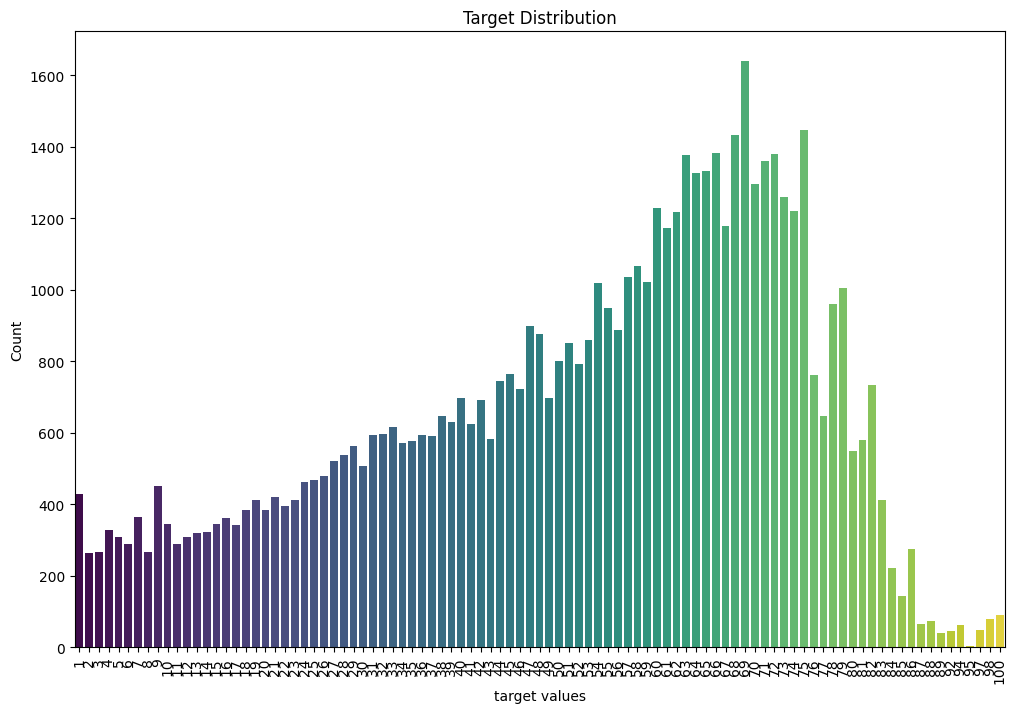

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

class_bal = y.value_counts(normalize=True)
class_bal

# 1. Target Distribution (Class Balance)
plt.figure(figsize=(12, 8))
sns.countplot(data=train_df, x='target', hue='target', palette='viridis', legend=False)
plt.title("Target Distribution")
plt.xlabel("target values")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

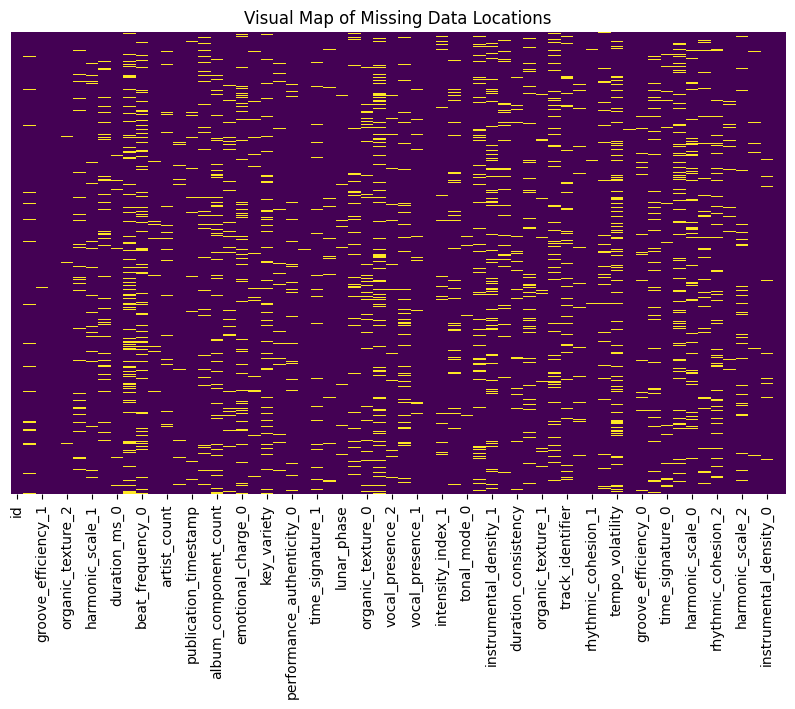

In [8]:
# Plots a heatmap where black is data, and yellow/white are missing values
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Visual Map of Missing Data Locations")
plt.show()

In [9]:
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_features

['emotional_charge_2',
 'groove_efficiency_1',
 'beat_frequency_1',
 'organic_texture_2',
 'harmonic_scale_1',
 'intensity_index_0',
 'duration_ms_0',
 'album_name_length',
 'beat_frequency_0',
 'beat_frequency_2',
 'artist_count',
 'album_component_count',
 'emotional_charge_1',
 'emotional_charge_0',
 'tonal_mode_2',
 'key_variety',
 'performance_authenticity_2',
 'performance_authenticity_0',
 'time_signature_1',
 'duration_ms_2',
 'instrumental_density_2',
 'organic_texture_0',
 'vocal_presence_2',
 'tonal_mode_1',
 'vocal_presence_1',
 'vocal_presence_0',
 'intensity_index_1',
 'organic_immersion_0',
 'tonal_mode_0',
 'groove_efficiency_2',
 'instrumental_density_1',
 'organic_immersion_2',
 'duration_consistency',
 'organic_texture_1',
 'rhythmic_cohesion_0',
 'emotional_resonance_1',
 'rhythmic_cohesion_1',
 'performance_authenticity_1',
 'tempo_volatility',
 'organic_immersion_1',
 'groove_efficiency_0',
 'emotional_resonance_2',
 'time_signature_0',
 'duration_ms_1',
 'harmoni

In [10]:
X[numerical_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61609 entries, 0 to 61608
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   emotional_charge_2          59167 non-null  float64
 1   groove_efficiency_1         61429 non-null  float64
 2   beat_frequency_1            61223 non-null  float64
 3   organic_texture_2           61226 non-null  float64
 4   harmonic_scale_1            58304 non-null  float64
 5   intensity_index_0           55638 non-null  float64
 6   duration_ms_0               60320 non-null  float64
 7   album_name_length           52015 non-null  float64
 8   beat_frequency_0            51878 non-null  float64
 9   beat_frequency_2            59843 non-null  float64
 10  artist_count                58348 non-null  float64
 11  album_component_count       57246 non-null  float64
 12  emotional_charge_1          57595 non-null  float64
 13  emotional_charge_0          555

In [11]:
import pandas as pd
import numpy as np

# Find the most recent date in the training set to act as our "present day" anchor
# We calculate this once and pass it to both train and test sets to maintain consistency
reference_date = pd.to_datetime(train_df['publication_timestamp']).max()

def engineer_features(df, ref_date):
    """Applies temporal and interaction feature engineering to a dataframe."""
    df_eng = df.copy()
    
    # --- 1. Temporal Feature: Track Age ---
    df_eng['publication_timestamp'] = pd.to_datetime(df_eng['publication_timestamp'])
    df_eng['track_age_days'] = (ref_date - df_eng['publication_timestamp']).dt.days
    
    # Fill missing ages with the median age of that specific dataframe
    median_age = df_eng['track_age_days'].median()
    df_eng['track_age_days'] = df_eng['track_age_days'].fillna(median_age)
    
    # --- 2. Interaction Features (Ratios) ---
    # Adding 1e-5 prevents division by zero if a denominator happens to be 0
    df_eng['beat_to_groove_ratio'] = df_eng['beat_frequency_1'] / (df_eng['groove_efficiency_1'] + 1e-5)
    df_eng['intensity_to_duration'] = df_eng['intensity_index_0'] / (df_eng['duration_ms_0'] + 1e-5)
    df_eng['organic_density'] = df_eng['organic_texture_1'] * df_eng['instrumental_density_1']
    
    return df_eng

print("Applying feature engineering to train and test sets...")
# Overwrite the original dataframes with the engineered versions
train_df = engineer_features(train_df, reference_date)
test_df = engineer_features(test_df, reference_date)

# Drop the raw timestamp column since we've extracted the track age
train_df = train_df.drop('publication_timestamp', axis=1)
test_df = test_df.drop('publication_timestamp', axis=1)
print("Feature engineering complete! Ready for Mutual Information calculation.")

Applying feature engineering to train and test sets...
Feature engineering complete! Ready for Mutual Information calculation.


In [12]:
X = train_df.drop(['id', 'target'], axis=1)
y = train_df['target']

In [13]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

numerical_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_features = train_df[numerical_features].copy()
imp_median = SimpleImputer(missing_values=np.nan, strategy='median')

mi_scores = mutual_info_classif(imp_median.fit_transform(num_features), y)
mi_scores

array([2.24504678, 2.3424946 , 2.28031479, 1.8065636 , 0.06867531,
       1.28687239, 2.27151803, 0.26087314, 1.89244188, 2.22301939,
       0.02248518, 0.27963909, 2.18216773, 2.07842392, 0.01489085,
       0.01517813, 1.20829403, 1.29690822, 0.01956347, 2.27849746,
       1.09344379, 1.66596119, 1.4104507 , 0.00796181, 1.46385475,
       1.48417046, 1.35480079, 2.20430797, 0.01724205, 2.10474568,
       1.01702797, 2.13903961, 2.22570179, 1.73946542, 1.1572951 ,
       1.43362492, 1.28743281, 1.21139694, 1.89612231, 2.36354549,
       2.28054656, 1.36118733, 0.02589526, 1.93843374, 0.07076745,
       0.02829057, 1.17563634, 1.45746989, 0.08301188, 1.4045643 ,
       1.22612351, 1.64342352, 2.34436563, 2.06521486, 1.09760635])

In [14]:
num_mi = pd.Series(mi_scores, index=num_features.columns).sort_values(ascending=False)
num_mi

organic_immersion_1           2.363545
beat_to_groove_ratio          2.344366
groove_efficiency_1           2.342495
groove_efficiency_0           2.280547
beat_frequency_1              2.280315
duration_ms_2                 2.278497
duration_ms_0                 2.271518
emotional_charge_2            2.245047
duration_consistency          2.225702
beat_frequency_2              2.223019
organic_immersion_0           2.204308
emotional_charge_1            2.182168
organic_immersion_2           2.139040
groove_efficiency_2           2.104746
emotional_charge_0            2.078424
intensity_to_duration         2.065215
duration_ms_1                 1.938434
tempo_volatility              1.896122
beat_frequency_0              1.892442
organic_texture_2             1.806564
organic_texture_1             1.739465
organic_texture_0             1.665961
track_age_days                1.643424
vocal_presence_0              1.484170
vocal_presence_1              1.463855
emotional_resonance_0    

In [15]:
numerical_features = num_mi.head(40).index.astype(str).tolist()

In [16]:
X[numerical_features].isnull().sum()/len(X[numerical_features]) *100

organic_immersion_1            0.223993
beat_to_groove_ratio           0.918697
groove_efficiency_1            0.292165
groove_efficiency_0            2.395754
beat_frequency_1               0.626532
duration_ms_2                  1.830901
duration_ms_0                  2.092227
emotional_charge_2             3.963707
duration_consistency           4.994400
beat_frequency_2               2.866464
organic_immersion_0            6.237725
emotional_charge_1             6.515282
organic_immersion_2            9.146391
groove_efficiency_2            9.326559
emotional_charge_0             9.907643
intensity_to_duration         11.585970
duration_ms_1                 14.778685
tempo_volatility              16.908244
beat_frequency_0              15.794770
organic_texture_2              0.621662
organic_texture_1              3.454041
organic_texture_0              7.039556
track_age_days                 0.000000
vocal_presence_0               0.178545
vocal_presence_1               1.404016


In [17]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
categorical_features

['composition_label_0',
 'composition_label_1',
 'weekday_of_release',
 'season_of_release',
 'lunar_phase',
 'creator_collective',
 'composition_label_2',
 'track_identifier']

In [18]:
X[categorical_features].describe()

,composition_label_0,composition_label_1,weekday_of_release,season_of_release,lunar_phase,creator_collective,composition_label_2,track_identifier
count,58660,60149,56551,61136,60608,52695,57146,57173
unique,21709,22930,7,4,4,15139,22169,22991
top,Intro,Refrigerator Door,Friday,summer,waning,"Various Artists,",Even Though I'm Leaving,Certified Lover Boy
freq,1640,109,27479,16140,15266,1735,100,94


In [19]:
categorical_features = ['weekday_of_release', 'season_of_release', 'lunar_phase']

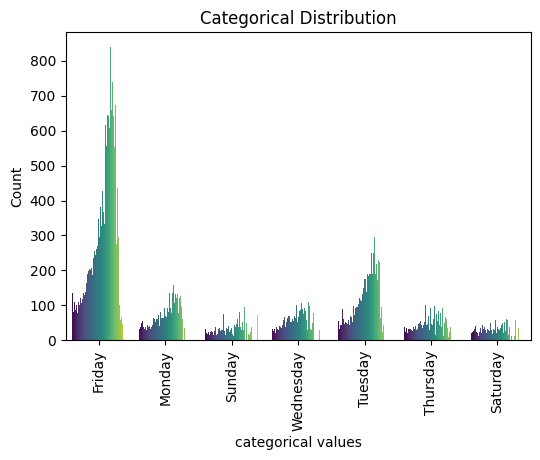

In [20]:
# 1. Target Distribution (Class Balance)
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='weekday_of_release', hue='target', palette='viridis', legend=False)
plt.title("Categorical Distribution")
plt.xlabel("categorical values")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

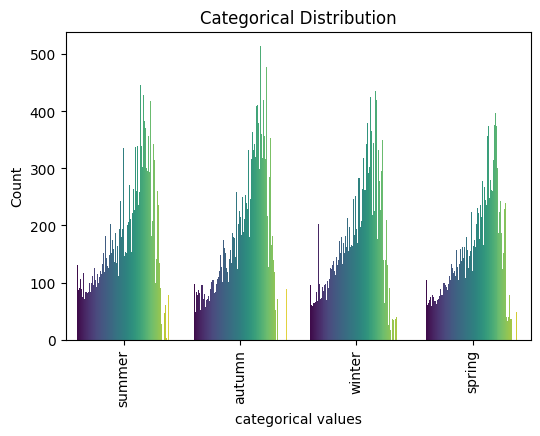

In [21]:
# 1. Target Distribution (Class Balance)
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='season_of_release', hue='target', palette='viridis', legend=False)
plt.title("Categorical Distribution")
plt.xlabel("categorical values")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

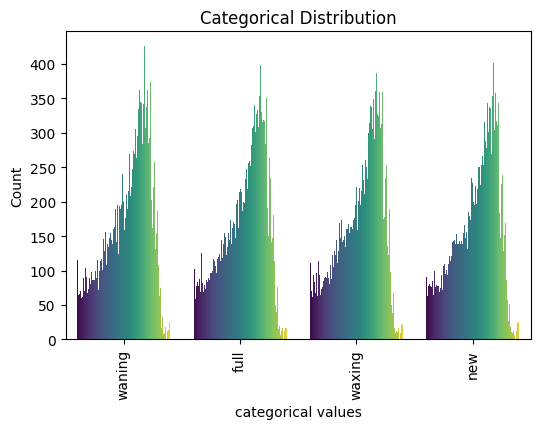

In [22]:
# 1. Target Distribution (Class Balance)
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='lunar_phase', hue='target', palette='viridis', legend=False)
plt.title("Categorical Distribution")
plt.xlabel("categorical values")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

In [23]:
X[categorical_features].isnull().sum()/len(X[categorical_features]) *100

weekday_of_release    8.209839
season_of_release     0.767745
lunar_phase           1.624763
dtype: float64

In [24]:
selected_X = pd.concat([train_df[categorical_features], train_df[numerical_features]], axis=1)
selected_X

,weekday_of_release,season_of_release,lunar_phase,organic_immersion_1,beat_to_groove_ratio,groove_efficiency_1,groove_efficiency_0,beat_frequency_1,duration_ms_2,duration_ms_0,...,intensity_index_1,performance_authenticity_0,rhythmic_cohesion_1,intensity_index_0,instrumental_density_0,performance_authenticity_1,performance_authenticity_2,rhythmic_cohesion_2,rhythmic_cohesion_0,organic_density
0,Friday,summer,waning,0.307521,68.435862,1.169231,1.150146,80.018,189853.0,154586.0,...,NaN,0.3360,0.649,0.789,0.000000,0.3170,0.1120,NaN,0.685,0.000000
1,Monday,summer,waning,0.339768,111.982512,1.321321,NaN,147.966,123272.0,46874.0,...,0.880,0.7520,0.665,0.715,0.043200,0.0825,0.1720,0.843,0.523,0.000000
2,NaN,autumn,full,0.062464,111.240040,1.285319,1.270758,142.980,302686.0,264665.0,...,0.928,0.1890,0.721,NaN,0.000000,0.3970,0.0828,NaN,NaN,0.000000
3,Friday,autumn,full,0.067538,96.184685,1.279435,1.145485,123.063,187126.0,209208.0,...,0.815,0.1820,0.636,0.685,0.000335,0.1630,0.1560,0.702,0.597,0.000000
4,NaN,winter,waxing,0.112618,136.136871,0.974906,1.124836,132.722,6413.0,215346.0,...,0.777,0.6970,0.796,0.856,0.000000,0.1210,0.0000,0.000,0.760,0.000009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61604,Friday,winter,waxing,0.959694,111.142067,0.809917,0.691834,90.017,240432.0,218490.0,...,0.588,0.0878,0.725,0.449,0.000000,0.3550,0.1220,0.742,0.648,0.000000
61605,NaN,summer,waxing,1.530589,103.771879,1.185022,0.889752,122.973,142186.0,259746.0,...,0.538,0.0695,0.453,0.573,0.000170,0.1900,0.1240,0.869,NaN,0.000000
61606,Sunday,summer,waxing,2.030795,257.693723,0.469714,0.632212,121.045,30253.0,79093.0,...,0.411,0.1250,0.874,0.526,0.101000,0.0788,0.1190,0.515,0.831,0.231426
61607,Friday,winter,waning,0.353800,64.177399,1.486339,1.866370,95.390,207133.0,208906.0,...,0.816,0.1310,0.548,0.838,0.000131,0.3350,0.1020,0.676,0.448,0.000000


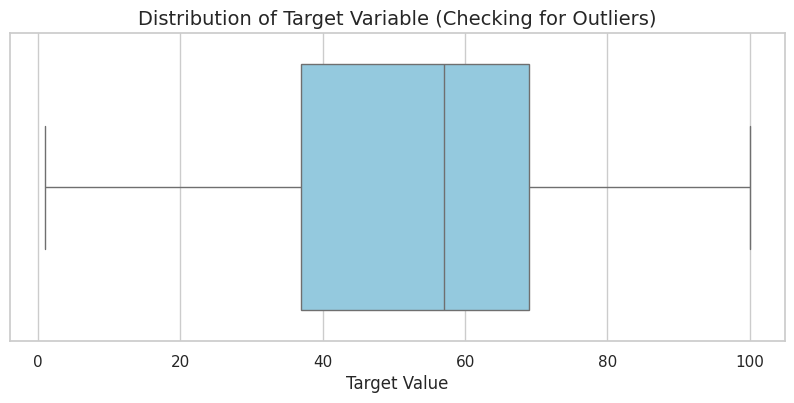

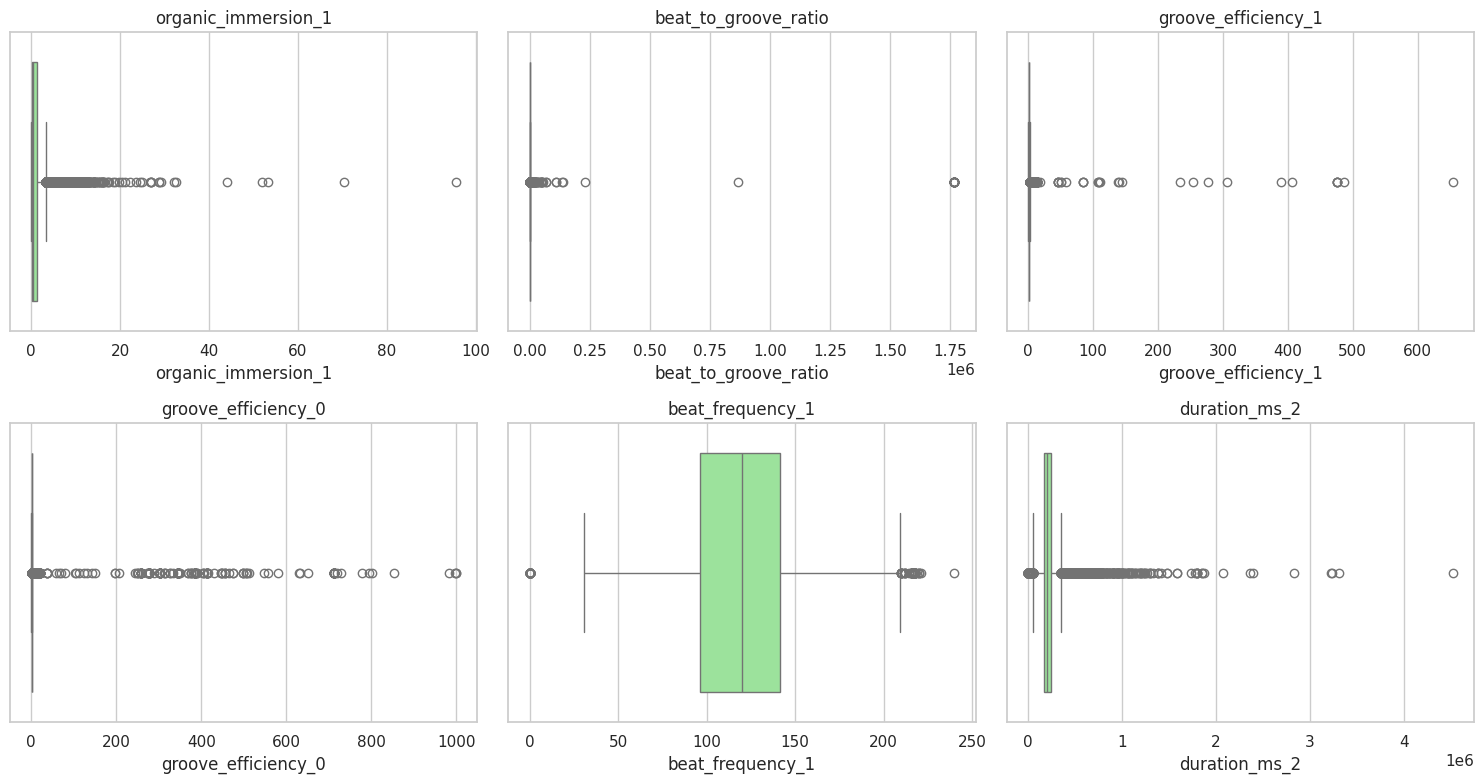

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for your report images
sns.set_theme(style="whitegrid")

# 1. Check the Target Variable for Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=train_df['target'], color='skyblue')
plt.title('Distribution of Target Variable (Checking for Outliers)', fontsize=14)
plt.xlabel('Target Value')
plt.show()

# 2. Check the Top 6 Numerical Features for Outliers
# We use the top 6 from your Mutual Information scores
top_6_features = num_mi.head(6).index.astype(str).tolist()

plt.figure(figsize=(15, 8))
for i, col in enumerate(top_6_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=train_df[col], color='lightgreen')
    plt.title(f'{col}', fontsize=12)

plt.tight_layout()
plt.show()

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [27]:
from sklearn.compose import ColumnTransformer

numerical_features = [str(col) for col in numerical_features]
categorical_features = [str(col) for col in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features),
        ('cat', cat_transformer, categorical_features)
    ]
)

{'regressor__n_estimators': 300,
 'regressor__min_samples_split': 10,
 'regressor__max_features': 1.0,
 'regressor__max_depth': None}

In [28]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

print("Setting up the Stacking Regressor...")

base_models = [
    ('rf', RandomForestRegressor(
        n_estimators=300, 
        min_samples_split=10, 
        max_features=1.0, 
        n_jobs=-1, 
        random_state=42
    )),
    ('xgb', XGBRegressor(
        n_estimators=400, 
        learning_rate=0.05, 
        max_depth=5, 
        subsample=0.8, 
        colsample_bytree=0.8, 
        reg_lambda=1.0,
        n_jobs=-1, 
        random_state=42
    ))
]

meta_model = Ridge()

stacking_ensemble = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3,          
    n_jobs=-1
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor), # Still using our KNN imputer and engineered features!
    ('stacker', stacking_ensemble)
])

Setting up the Stacking Regressor...


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
print("Training Version 6 (Stacking Ensemble)... Go grab a coffee, this will take a few minutes!")
model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred_stack = model.predict(X_val)

Training Version 6 (Stacking Ensemble)... Go grab a coffee, this will take a few minutes!


In [31]:
y_val

31893    41
11527    98
49596    66
37300    63
38601    25
         ..
35039    60
23893    73
25527    31
58409    74
16946    57
Name: target, Length: 12322, dtype: int64

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse_stack = mean_squared_error(y_val, y_pred_stack)
rmse_stack = np.sqrt(mse_stack)
mae_stack = mean_absolute_error(y_val, y_pred_stack)
r2_stack = r2_score(y_val, y_pred_stack)

print("\n--- Phase 4: Stacking Ensemble Evaluation ---")
print(f"Validation MSE:  {mse_stack:.4f}")
print(f"Validation RMSE: {rmse_stack:.4f} (Target to beat: 10.9101)")
print(f"Validation MAE:  {mae_stack:.4f}")
print(f"Validation R2:   {r2_stack:.4f}")


--- Phase 4: Stacking Ensemble Evaluation ---
Validation MSE:  115.8201
Validation RMSE: 10.7620 (Target to beat: 10.9101)
Validation MAE:  6.6577
Validation R2:   0.7513


In [33]:
y_pred = model.predict(test_df.drop('id', axis=1))

In [34]:
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'target': y_pred
})
submission_df.to_csv('submission3.csv', index=False)
submission_df.head()

,id,target
0,25174,42.351274
1,38453,69.137399
2,29013,69.079062
3,57463,68.226883
4,51264,36.935498
